<a href="https://colab.research.google.com/github/eusmani/ML-basics/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of customer records: 200
   customer_id  gender  age  annual_income  spending_score
0            1    Male   19             15              39
1            2    Male   21             15              81
2            3  Female   20             16               6
3            4  Female   23             16              77
4            5  Female   31             17              40


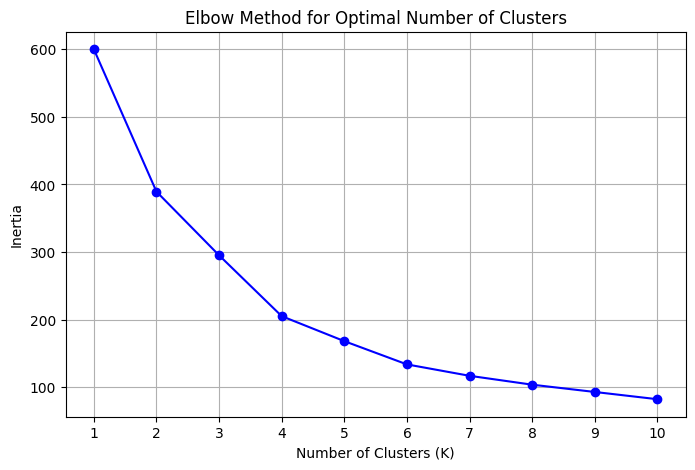


Cluster Characteristics:
         annual_income  spending_score    age
cluster                                      
0                26.75           18.35  46.25
1                41.09           62.24  25.19
2                86.10           81.53  32.88
3                86.10           19.36  39.87
4                54.38           48.85  55.64

Cluster 0 Marketing Strategy:
Lower-engagement customers: Send re-engagement offers and coupons.

Cluster 1 Marketing Strategy:
High-engagement customers: Offer discounts and membership programs.

Cluster 2 Marketing Strategy:
High-value customers: Offer exclusive promotions and loyalty rewards.

Cluster 3 Marketing Strategy:
High-income, low-spending customers: Use personalized recommendations.

Cluster 4 Marketing Strategy:
Lower-engagement customers: Send re-engagement offers and coupons.

Saved customer segments to customer_segments.csv
Saved elbow graph to elbow_plot.png


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Data source: Mall Customers Dataset
# https://github.com/MatthewChatham/ames/blob/master/train.csv


# Data source: Mall Customers Dataset
# https://raw.githubusercontent.com/tanishq21/Mall-Customers/refs/heads/main/Mall_Customers.csv

url = "https://raw.githubusercontent.com/tanishq21/Mall-Customers/refs/heads/main/Mall_Customers.csv"

df = pd.read_csv(url)

df = df.rename(columns={
    "CustomerID": "customer_id",
    "Genre": "gender",
    "Age": "age",
    "Annual Income (k$)": "annual_income",
    "Spending Score (1-100)": "spending_score"
})

print("Number of customer records:", len(df))
print(df.head())

# Select numerical features for clustering
features = ["annual_income", "spending_score", "age"]
X = df[features]

# Scale the numerical data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the elbow method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, "bo-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(list(K))
plt.grid(True)
plt.savefig("elbow_plot.png")
plt.show()

# Choose K based on the elbow plot
optimal_k = 5

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

# Analyze the average characteristics of each cluster
cluster_summary = df.groupby("cluster")[features].mean().round(2)

print("\nCluster Characteristics:")
print(cluster_summary)

# Create marketing strategies for each cluster
overall_income = df["annual_income"].mean()
overall_spending = df["spending_score"].mean()

for cluster in sorted(df["cluster"].unique()):
    income = cluster_summary.loc[cluster, "annual_income"]
    spending = cluster_summary.loc[cluster, "spending_score"]

    print(f"\nCluster {cluster} Marketing Strategy:")

    if income > overall_income and spending > overall_spending:
        print("High-value customers: Offer exclusive promotions and loyalty rewards.")
    elif income > overall_income and spending < overall_spending:
        print("High-income, low-spending customers: Use personalized recommendations.")
    elif income < overall_income and spending > overall_spending:
        print("High-engagement customers: Offer discounts and membership programs.")
    else:
        print("Lower-engagement customers: Send re-engagement offers and coupons.")

# Save customer cluster assignments
df.to_csv("customer_segments.csv", index=False)

print("\nSaved customer segments to customer_segments.csv")
print("Saved elbow graph to elbow_plot.png")